In [1]:
# script to generate the udpated precision recall curves with indels included

In [1]:
# import packages
import pandas as pd
import os
from tqdm import tqdm
import torch
import matplotlib.pyplot as mpl
import seaborn as sns
import numpy as np
from sklearn import metrics
from scipy import stats
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import precision_recall_curve
from sklearn.metrics import PrecisionRecallDisplay
from collections import Counter

In [9]:
# Open GTEx PRC Dataframe  -  with indels
gtex_prc_df = pd.read_csv('../raw_data/gtex.paired.mpra.prc.with.indels.mal.cell.types.txt',
                          sep = '\t')
# Open Traits PRC Dataframe - with indels
traits_prc_df = pd.read_csv('../raw_data/traits.paired.mpra.prc.with.indels.mal.cell.types.txt',
                            sep = '\t')

In [10]:
# get the number of indels
# gtex
gtex_indel_check = gtex_prc_df.copy()
# filter for only indels < 10bp
gtex_indel_check = gtex_indel_check[(gtex_indel_check['allele1'].str.len() <= 10) & (gtex_indel_check['allele2'].str.len() <= 10)]
gtex_snp_bool = (gtex_indel_check['allele1'].str.len() == 1) & (gtex_indel_check['allele2'].str.len() == 1)
print(f'there are {len(gtex_indel_check.loc[~gtex_snp_bool])} indels in the gtex test set')
# traits
traits_indel_check = traits_prc_df.copy()
# filter for only indels < 10bp
traits_indel_check = traits_indel_check[(traits_indel_check['allele1'].str.len() <= 10) & (traits_indel_check['allele2'].str.len() <= 10)]
traits_snp_bool = (traits_indel_check['allele1'].str.len() == 1) & (traits_indel_check['allele2'].str.len() == 1)
print(f'there are {len(traits_indel_check.loc[~traits_snp_bool])} indels in the ukbb test set')

there are 1652 indels in the gtex test set
there are 189 indels in the ukbb test set


In [11]:
# define function to return DF of Precision and Recall of Experimental for CRE, emVar, and emVar + CRE
def empirical_precision_recall (df, library):
    # make binary list of true positives
    causal_true_false = [1 if i == True else 0 for i in df['causal']]
    # CRE
    # make list of hits/misses
    cre_hit_miss = [1 if i == 1 else 0 for i in df['CRE']]
    # calculate precision
    cre_precision = precision_score(causal_true_false,
                                    cre_hit_miss)
    # calculate recall
    cre_recall = recall_score(causal_true_false,
                              cre_hit_miss)
    # emVar
    # make list of hits/misses
    emvar_hit_miss = [1 if i == True else 0 for i in df['emVar_any']]
    # calculate precision
    emvar_precision = precision_score(causal_true_false,
                                      emvar_hit_miss)
    # calculate recall
    emvar_recall = recall_score(causal_true_false,
                                emvar_hit_miss)
    # emVar + CRE
    # make list of hits/misses
    emvar_cre_hit_miss = [1 if i == True and j == 1 else 0 for i,j in zip(df['emVar_any'],
                                                                          df['CRE'])]
    # calculate precision
    emvar_cre_precision = precision_score(causal_true_false,
                                          emvar_cre_hit_miss)
    # calculate recall
    emvar_cre_recall = recall_score(causal_true_false,
                                    emvar_cre_hit_miss)
    # make a DataFrame of Precision and Recall by Category
    prc_df = pd.DataFrame({'category' : [f'{library}: CRE', f'{library}: emVar', f'{library}: emVar + CRE'],
                           'precision' : [cre_precision, emvar_precision, emvar_cre_precision],
                           'recall' : [cre_recall, emvar_recall, emvar_cre_recall]})
    return prc_df

In [12]:
# define function to return DF of Precision and Recall of Experimental for CRE, emVar, and emVar + CRE
def empirical_precision_recall (df, library):
    # make binary list of true positives
    causal_true_false = [1 if i == True else 0 for i in df['causal']]
    # CRE
    # make list of hits/misses
    cre_hit_miss = [1 if i == 1 else 0 for i in df['CRE']]
    # calculate precision
    cre_precision = precision_score(causal_true_false,
                                    cre_hit_miss)
    # calculate recall
    cre_recall = recall_score(causal_true_false,
                              cre_hit_miss)
    # emVar
    # make list of hits/misses
    emvar_hit_miss = [1 if i == True else 0 for i in df['emVar_any']]
    # calculate precision
    emvar_precision = precision_score(causal_true_false,
                                      emvar_hit_miss)
    # calculate recall
    emvar_recall = recall_score(causal_true_false,
                                emvar_hit_miss)
    # emVar + CRE
    # make list of hits/misses
    emvar_cre_hit_miss = [1 if i == True and j == 1 else 0 for i,j in zip(df['emVar_any'],
                                                                          df['CRE'])]
    # calculate precision
    emvar_cre_precision = precision_score(causal_true_false,
                                          emvar_cre_hit_miss)
    # calculate recall
    emvar_cre_recall = recall_score(causal_true_false,
                                    emvar_cre_hit_miss)
    # make a DataFrame of Precision and Recall by Category
    prc_df = pd.DataFrame({'category' : [f'{library}: CRE', f'{library}: emVar', f'{library}: emVar + CRE'],
                           'precision' : [cre_precision, emvar_precision, emvar_cre_precision],
                           'recall' : [cre_recall, emvar_recall, emvar_cre_recall]})
    return prc_df

In [13]:
# open merged ukbb/gtex blacklist filtered predictions
all_mpac_ukbb_gtex = pd.read_csv('../processed_data/all.gtex.traits.mpra.blacklist.filtered.v1.with.updated.indel.preds.tsv',
                                 sep = '\t',
                                 low_memory=False)

In [14]:
# open the ukbb liftover for variant filtering
ukbb_hg38_liftover = pd.read_csv('../processed_data/ukbb_prc_with_indels_hg38_lifted.bed', sep = '\t', header = None)

In [16]:
# merge predictions and prc dfs
# gtex
gtex_merge = gtex_prc_df.filter(['variant', 'CRE', 'emVar_any', 'causal']).merge(
    all_mpac_ukbb_gtex.filter(['variant', 'id', 'k562_skew_pred_avg', 'hepg2_skew_pred_avg', 'sknsh_skew_pred_avg']),
    how='inner',
    on='variant'
).drop_duplicates()
# traits
traits_merge = traits_prc_df.filter(['variant', 'CRE', 'emVar_any', 'causal']).merge(
    all_mpac_ukbb_gtex.filter(['variant', 'id', 'k562_skew_pred_avg', 'hepg2_skew_pred_avg', 'sknsh_skew_pred_avg']),
    how='inner',
    on='variant'
).drop_duplicates()

In [17]:
# open the sei predictions
sei_preds = pd.read_csv('../raw_data/ukbb_gtex_prc_with_indels_sei_dnase_preds_all_cell_types_dnase.tsv',
                        sep = '\t')
# filter for DNase predictions
sei_pred_cols = [i for i in sei_preds.keys() if 'DNase' in i]
# get max prediction for each variant
maxCol = lambda x: max(x.min(), x.max(), key=abs)
sei_preds['sei_max_pred'] = sei_preds.filter(sei_pred_cols).apply(maxCol,
                                                                  axis=1)
# add hg38 id to sei preds for merging with malinois preds
sei_preds['id'] = [(':').join([chrom,
                               str(pos),
                               ref,
                               alt]) for chrom,
                                         pos,
                                         ref,
                                         alt in zip(sei_preds['chrom'],
                                                    sei_preds['pos'],
                                                    sei_preds['ref'],
                                                    sei_preds['alt'])]
# filter sei preds for gtex
gtex_sei = sei_preds[sei_preds['id'].isin(gtex_merge['id'])].drop_duplicates().filter(['id',
                                                                                       'sei_max_pred'])
# filter sei preds for ukbb
ukbb_sei = sei_preds[sei_preds['id'].isin(traits_merge['id'])].copy().drop_duplicates().filter(['id',
                                                                                                'sei_max_pred'])
# merge with other datasets
gtex_merge_sei = gtex_merge.merge(gtex_sei, on='id')
# merge with other data
traits_merge_sei = traits_merge.merge(ukbb_sei, on='id')

In [18]:
# open deltaSVM predictions
# gtex
gtex_hepg2_deltaSVM = pd.read_csv('../raw_data/deltaSVM_preds/SupplementaryTable_hepg2weights_gtex_prc_with_indels_deltaSVM_preds.txt',
                                  sep = '\t',
                                  header = None,
                                  names = ['variant',
                                           'gtex_hepg2_deltaSVM'])
gtex_k562_deltaSVM = pd.read_csv('../raw_data/deltaSVM_preds/SupplementaryTable_k562weights_gtex_prc_with_indels_deltaSVM_preds.txt',
                                 sep = '\t',
                                 header = None,
                                 usecols=[1],
                                 names = ['gtex_k562_deltaSVM'])
# combine gtex predictions into single DF
all_gtex_deltaSVM = pd.concat([gtex_hepg2_deltaSVM,
                               gtex_k562_deltaSVM], axis=1, join='outer')
# add a max column for hepg2/k562
all_gtex_deltaSVM.loc[:,'max_deltaSVM'] = [max([k, h], key=abs) for h,k in zip(all_gtex_deltaSVM['gtex_hepg2_deltaSVM'],
                                                                               all_gtex_deltaSVM['gtex_k562_deltaSVM'])]
# revise variant id for matching
all_gtex_deltaSVM.loc[:, 'variant'] = [f'chr{i}' for i in all_gtex_deltaSVM['variant']]
# traits
traits_hepg2_deltaSVM = pd.read_csv('../raw_data/deltaSVM_preds/SupplementaryTable_hepg2weights_ukbb_bbj_prc_with_indels_deltaSVM_preds.txt',
                                  sep = '\t',
                                  header = None,
                                  names = ['variant',
                                           'ukbb_hepg2_deltaSVM'])
traits_k562_deltaSVM = pd.read_csv('../raw_data/deltaSVM_preds/SupplementaryTable_k562weights_ukbb_bbj_prc_with_indels_deltaSVM_preds.txt',
                                 sep = '\t',
                                 header = None,
                                 usecols=[1],
                                 names = ['ukbb_k562_deltaSVM'])
all_traits_deltaSVM = pd.concat([traits_hepg2_deltaSVM,
                                 traits_k562_deltaSVM], axis=1, join='outer')
# add a max column for hepg2/k562
all_traits_deltaSVM.loc[:,'max_deltaSVM'] = [max([k, h], key = abs) for h,k in zip(all_traits_deltaSVM['ukbb_hepg2_deltaSVM'],
                                                                                   all_traits_deltaSVM['ukbb_k562_deltaSVM'])]
# revise variant id for matching
all_traits_deltaSVM.loc[:, 'variant'] = [f'chr{i}' for i in all_traits_deltaSVM['variant']]

In [19]:
# add deltaSVM predictions to DF
# gtex
all_gtex_with_svm = gtex_merge_sei.merge(all_gtex_deltaSVM, on='variant', how='inner')
# ukbb
all_traits_with_svm = traits_merge_sei.merge(all_traits_deltaSVM, on='variant', how='inner')

In [20]:
# get information for tab20c palette
tab20c = sns.color_palette('tab20c').as_hex()
tab20b = sns.color_palette('tab20b').as_hex()
# GTeX
gtex_palette = {'MPAC' : '#9ecae1',
                'MPAC + CRE' : '#3182bd',
                'emVar' : '#3DB371',
                'emVar + CRE' : '#196533',
                'SEI DNase' : '#fd8d3c',
                'SEI + CRE' : '#e6550d',
                'deltaSVM' : '#e7ba52',
                'deltaSVM + CRE' : 'darkgoldenrod'}
traits_palette = {'MPAC' : '#9ecae1',
                'MPAC + CRE' : '#3182bd',
                'emVar' : '#3DB371',
                'emVar + CRE' : '#196533',
                'SEI DNase' : '#fd8d3c',
                'SEI + CRE' : '#e6550d',
                'deltaSVM' : '#e7ba52',
                'deltaSVM + CRE' : 'darkgoldenrod'}

In [31]:
def sklearn_precision_recall (merge_df,
                              cohort,
                              palette_dict,
                              ylim,
                              title,
                              save_fig,
                              sum_df2save):
    # annotate empirical true/false
    merge_df['emp_true'] = [1 if i == True else 0 for i in merge_df['causal']]
    # calculate empirical precision recall
    emp_prc = empirical_precision_recall(merge_df,
                                         cohort)
    ### no activity threshold ###
    # get max of hepg2, k562, sknsh skew
    merge_df['no_act_abs_max'] = [abs(max([k,
                                           h,
                                           s], key=abs)) for k,h,s in zip(merge_df['k562_skew_pred_avg'],
                                                                          merge_df['hepg2_skew_pred_avg'],
                                                                          merge_df['sknsh_skew_pred_avg'])]
    # calculate precision recall
    no_act_pre, no_act_rec, no_act_thresh = precision_recall_curve(merge_df['emp_true'],
                                                                   merge_df['no_act_abs_max'])
    no_act_auc = metrics.auc(no_act_rec,
                             no_act_pre)
    # make df for plotting
    no_act2plot = pd.DataFrame({'precision' : no_act_pre,
                                'recall' : no_act_rec,
                                'feature' : ['MPAC' for i in range(len(no_act_pre))],
                                'cohort' : [cohort for i in range(len(no_act_pre))]})
    # calculate no activity + CRE curve
    # refactor skew to account for CRE
    merge_df['no_act_cre_refactor'] = [skew if cre == 1 else 0 for skew, cre in zip(merge_df['no_act_abs_max'],
                                                                                    merge_df['CRE'])]
    # calculate precision recall
    no_act_cre_pre, no_act_cre_rec, no_act_cre_thresh = precision_recall_curve(merge_df['emp_true'],
                                                                               merge_df['no_act_cre_refactor'])
    # drop position so that we don't get line out to 1, .5
    no_act_cre_pre = no_act_cre_pre[1:]
    no_act_cre_rec = no_act_cre_rec[1:]
    no_act_cre_auc = metrics.auc(no_act_cre_rec,
                                 no_act_cre_pre)
    # make df for plotting
    no_act_cre2plot = pd.DataFrame({'precision' : no_act_cre_pre,
                                    'recall' : no_act_cre_rec,
                                    'feature' : ['MPAC + CRE' for i in range(len(no_act_cre_pre))],
                                    'cohort' : [cohort for i in range(len(no_act_cre_pre))]})
    # calculate sei prc
    # take absolute value of sei predictions
    merge_df['sei_abs_max'] = [abs(i) for i in merge_df['sei_max_pred']]
    sei_pre, sei_rec, sei_thresh = precision_recall_curve(merge_df['emp_true'],
                                                          merge_df['sei_abs_max'])
    sei_auc = metrics.auc(sei_rec,
                          sei_pre)
    sei2plot = pd.DataFrame({'precision' : sei_pre,
                             'recall' : sei_rec,
                             'feature' : ['SEI DNase' for i in range(len(sei_pre))],
                             'cohort' : [cohort for i in range(len(sei_pre))]})
    # calculate sei + CRE prc
    merge_df['sei_cre_refactor'] = [sei_skew if cre == 1 else 0 for sei_skew, cre in zip(merge_df['sei_abs_max'],
                                                                                         merge_df['CRE'])]
    # calculate precision recall
    sei_cre_pre, sei_cre_rec, sei_cre_thresh = precision_recall_curve(merge_df['emp_true'],
                                                                      merge_df['sei_cre_refactor'])
    # drop position so that we don't get line out to 1, .5
    sei_cre_pre = sei_cre_pre[1:]
    sei_cre_rec = sei_cre_rec[1:]
    sei_cre_auc = metrics.auc(sei_cre_rec,
                              sei_cre_pre)
    sei_cre2plot = pd.DataFrame({'precision' : sei_cre_pre,
                                 'recall' : sei_cre_rec,
                                 'feature' : ['SEI + CRE' for i in range(len(sei_cre_pre))],
                                 'cohort' : [cohort for i in range(len(sei_cre_pre))]})
    # calculate deltaSVM prc
    # take absolute value of deltaSVM predictions
    merge_df['deltaSVM_abs_max'] = [abs(i) for i in merge_df['max_deltaSVM']]
    deltaSVM_pre, deltaSVM_rec, deltaSVM_thresh = precision_recall_curve(merge_df['emp_true'],
                                                                         merge_df['deltaSVM_abs_max'])
    deltaSVM_auc = metrics.auc(deltaSVM_rec,
                               deltaSVM_pre)
    deltaSVM2plot = pd.DataFrame({'precision' : deltaSVM_pre,
                                  'recall' : deltaSVM_rec,
                                  'feature' : ['deltaSVM' for i in range(len(deltaSVM_pre))],
                                  'cohort' : [cohort for i in range(len(deltaSVM_pre))]})
    # calculate deltaSVM + CRE prc
    merge_df['deltaSVM_cre_refactor'] = [svm_skew if cre == 1 else 0 for svm_skew, cre in zip(merge_df['deltaSVM_abs_max'],
                                                                                              merge_df['CRE'])]
    svm_cre_pre, svm_cre_rec, svm_cre_thresh = precision_recall_curve(merge_df['emp_true'],
                                                                      merge_df['deltaSVM_cre_refactor'])
    # drop first position to end line at CRE
    svm_cre_pre = svm_cre_pre[1:]
    svm_cre_rec = svm_cre_rec[1:]
    svm_cre_auc = metrics.auc(svm_cre_rec,
                              svm_cre_pre)
    svm_cre2plot = pd.DataFrame({'precision' : svm_cre_pre,
                                 'recall' : svm_cre_rec,
                                 'feature' : ['deltaSVM + CRE' for i in range(len(svm_cre_rec))],
                                 'cohort' : [cohort for i in range(len(svm_cre_rec))]})
    # make a df for saving aucs and data descriptions (n positive/negative, total vars, etc) to disk
    summary_df = pd.DataFrame({'library' : [cohort],
                               'n_vars' : [len(merge_df)],
                               'n_causal' : [merge_df['emp_true'].tolist().count(1)],
                               'n_benign' : [merge_df['emp_true'].tolist().count(0)],
                               'no_act_auc' : [no_act_auc],
                               'no_act_cre_auc' : [no_act_cre_auc],
                               'sei_auc' : [sei_auc],
                               'sei_cre_auc' : [sei_cre_auc],
                               'deltaSVM_auc' : [deltaSVM_auc],
                               'deltaSVM_cre_auc' : [svm_cre_auc]})
    print(summary_df)
    # save summary df to file
    summary_df.to_csv(sum_df2save,
                     sep = '\t',
                     index = False)
    # plot PRC
    all2plot = pd.concat([no_act2plot,
                          no_act_cre2plot,
                          sei2plot,
                          sei_cre2plot,
                          deltaSVM2plot,
                          svm_cre2plot])
    mpl.figure(dpi=300)
    mpl.rcParams['pdf.fonttype'] = 42
    mpl.rcParams['ps.fonttype'] = 42
    sns.lineplot(data=all2plot,
                 x='recall',
                 y='precision',
                 hue='feature',
                 palette=palette_dict,
                 errorbar=None,
                 alpha=.75)
    mpl.xlabel('Recall')
    mpl.ylabel('Precision')
    # add empirical annotations
    # CRE
    sns.scatterplot(data=emp_prc[emp_prc.index == 0],
                    x='recall',
                    y='precision',
                    hue='category',
                    linewidth=0,
                    marker='s',
                    s=50)
    # emVar
    sns.scatterplot(data=emp_prc[emp_prc.index == 1],
                    x='recall',
                    y='precision',
                    hue='category',
                    linewidth=0,
                    marker='^',
                    s=50)
    # emVar + CRE
    sns.scatterplot(data=emp_prc[emp_prc.index == 2],
                    x='recall',
                    y='precision',
                    hue='category',
                    linewidth=0,
                    s=50)
    mpl.hlines(y=.5,
               xmin=0,
               xmax=1,
               color='k',
               linestyle='dashed')
    mpl.ylim(ylim)
    mpl.title(title, loc='left')
    sns.despine()
    mpl.savefig(save_fig)
    # calculate precision for MPAC at empirical recall levels for emVars and emVar + CRE
    # emVar alone — use closest recall value to avoid floating point exact match failures
    emp_recall_emvar = emp_prc[emp_prc.index == 1]['recall'].tolist()[0]
    closest_idx = np.argmin(np.abs(no_act_rec - emp_recall_emvar))
    mpac_pre_at_emp_rec = no_act_pre[closest_idx]
    print(f'MPAC Precision at empirical emVar recall: {mpac_pre_at_emp_rec}')

    # emVar + CRE — use closest recall value to avoid floating point exact match failures
    emp_recall_emvar_cre = emp_prc[emp_prc.index == 2]['recall'].tolist()[0]
    print(emp_recall_emvar_cre)
    closest_idx_cre = np.argmin(np.abs(no_act_cre_rec - emp_recall_emvar_cre))
    mpac_pre_at_emp_cre_rec = no_act_cre_pre[closest_idx_cre]
    print(f'MPAC Precision at empirical emVar + CRE recall: {mpac_pre_at_emp_cre_rec}')

    return merge_df, emp_prc;

  library  n_vars  n_causal  n_benign  no_act_auc  no_act_cre_auc   sei_auc  \
0    GTex   23676     11778     11898    0.606494         0.37287  0.670084   

   sei_cre_auc  deltaSVM_auc  deltaSVM_cre_auc  
0     0.386447      0.520798          0.344463  
MPAC Precision at empirical emVar recall: 0.6758417958311064
0.1531669213788419
MPAC Precision at empirical emVar + CRE recall: 0.8057168378740509


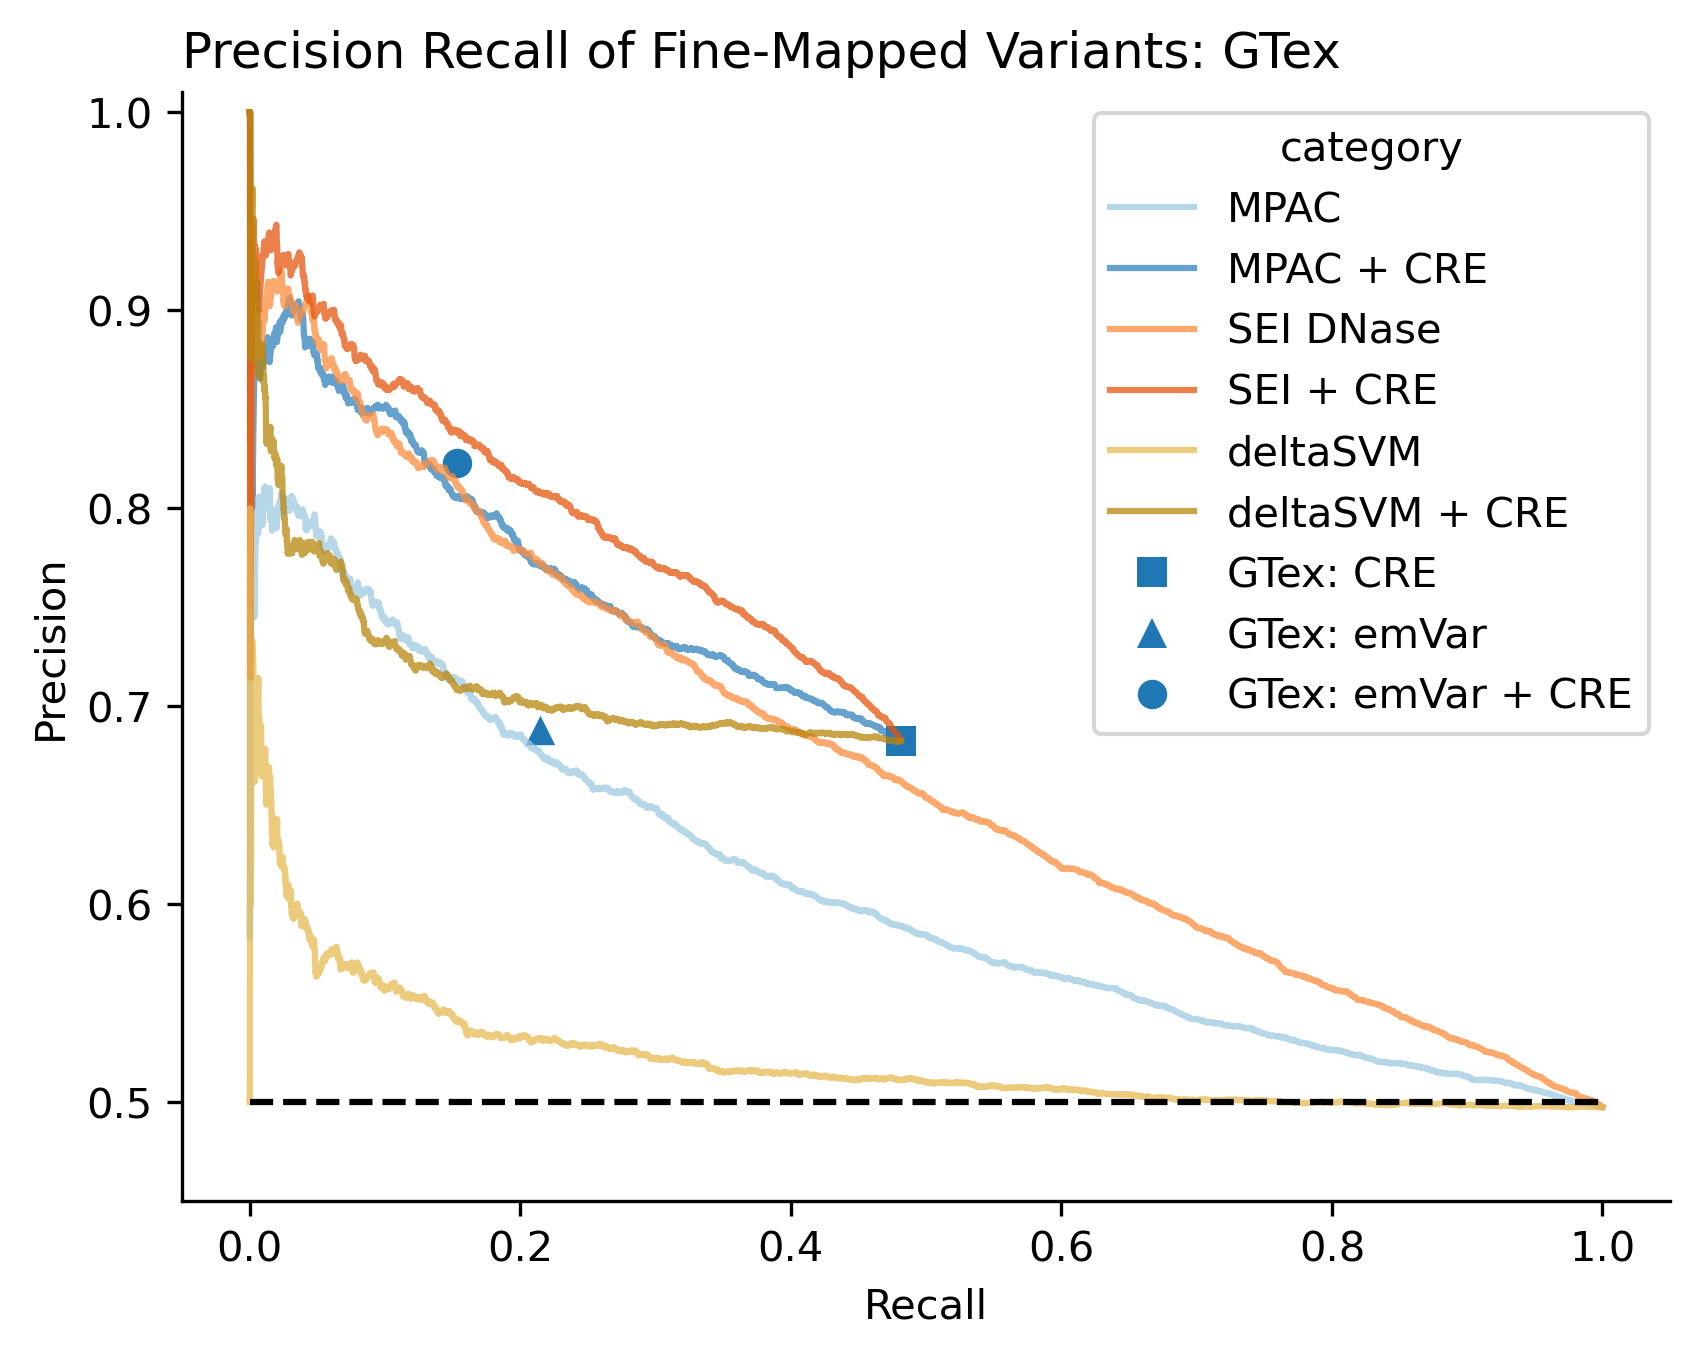

In [25]:
# plot GTeX - no activity filter
gtex_prc_df, gtex_emp_prc = sklearn_precision_recall(all_gtex_with_svm,
                         'GTex',
                         gtex_palette,
                         (.45,1.01),
                         'Precision Recall of Fine-Mapped Variants: GTex',
                         '../analysis/gtex_sklearn_prc_no_act_filter_with_indels_fig1e_rev1_v1.pdf',
                         '../analysis/gtex_prc_summary_with_indels_rev1.txt')

  library  n_vars  n_causal  n_benign  no_act_auc  no_act_cre_auc   sei_auc  \
0    UKBB    2014      1035       979    0.645825        0.430406  0.707482   

   sei_cre_auc  deltaSVM_auc  deltaSVM_cre_auc  
0     0.440942      0.559701          0.411334  


MPAC Precision at empirical emVar recall: 0.7216216216216216
0.20869565217391303
MPAC Precision at empirical emVar + CRE recall: 0.833976833976834


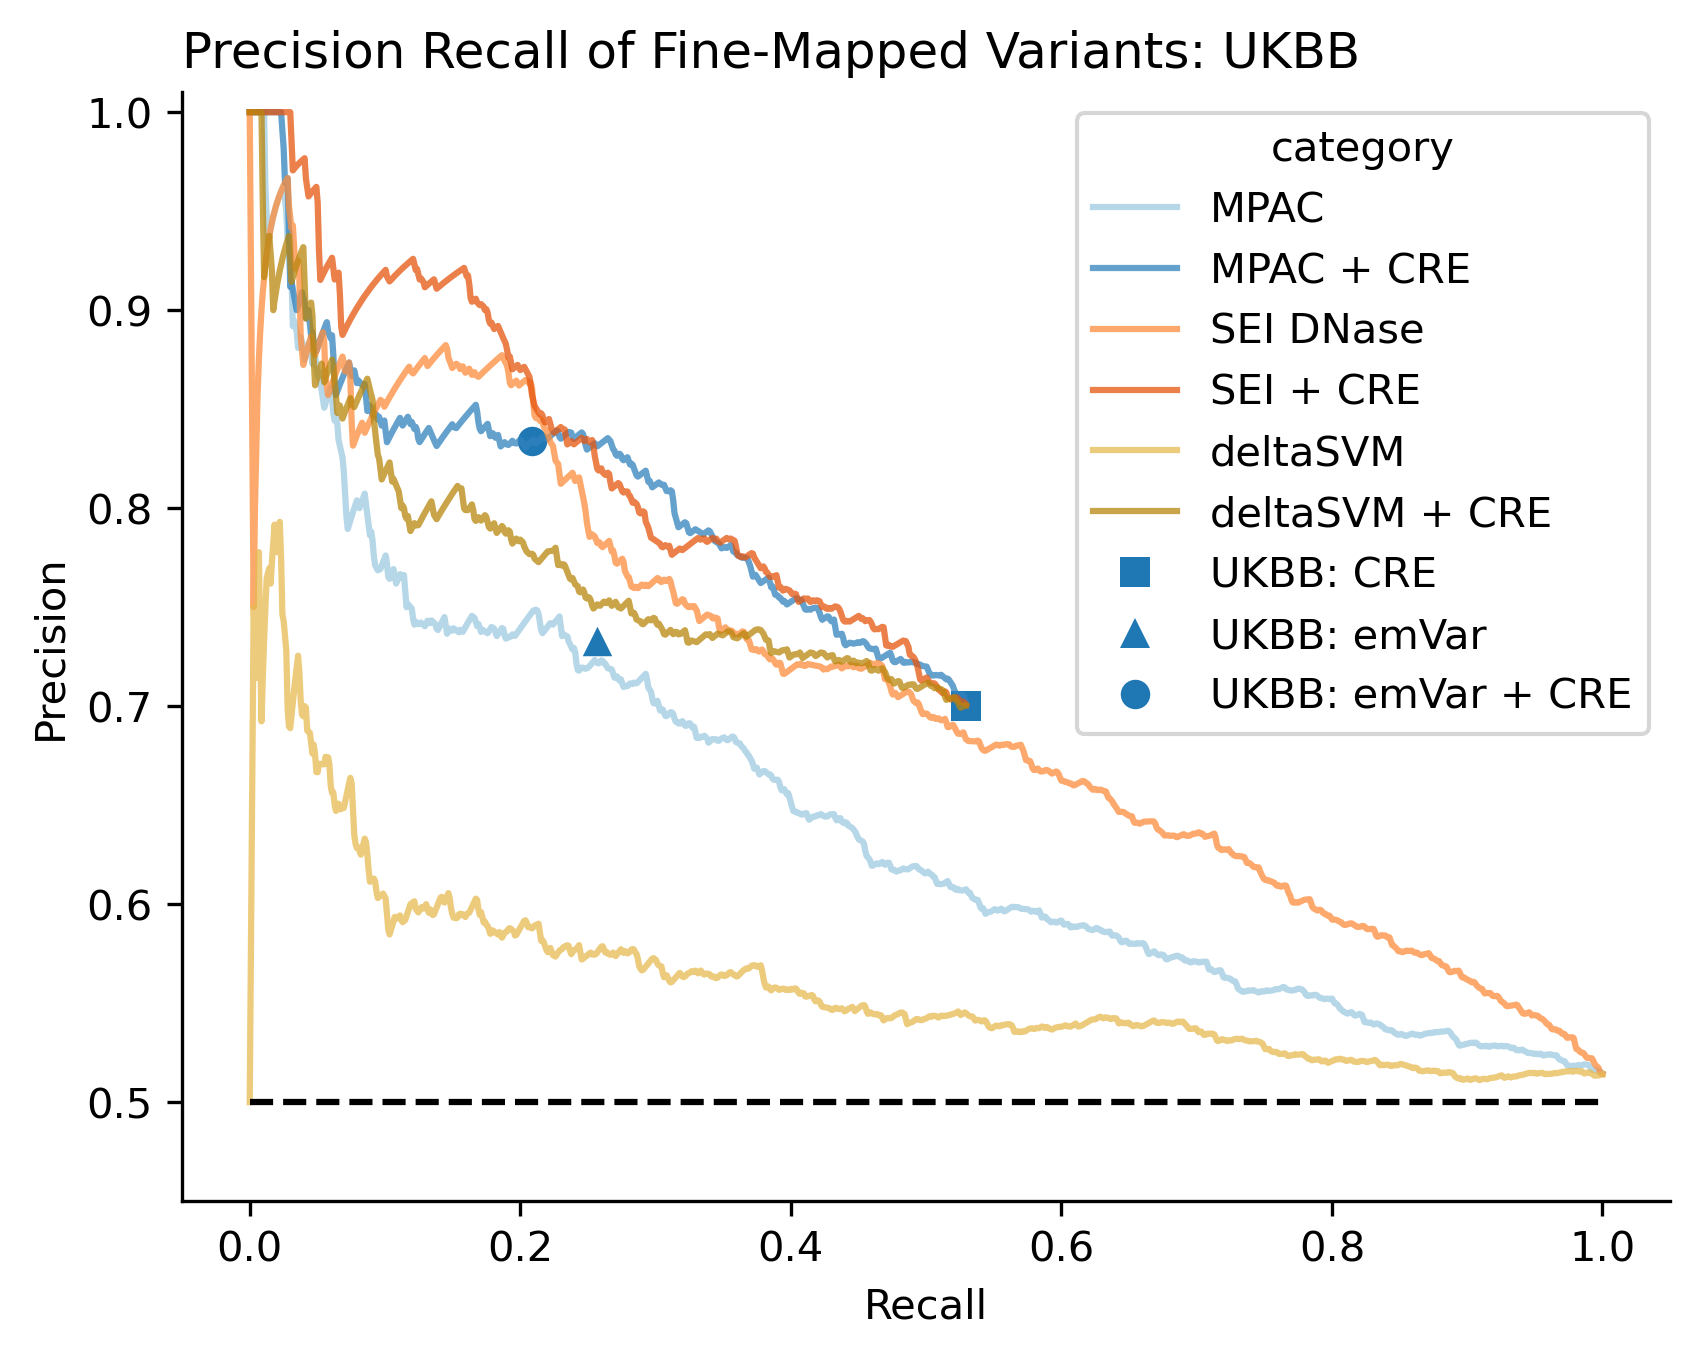

In [26]:
# plot UKBB - no activity filter
ukbb_prc_df, ukbb_emp_prc = sklearn_precision_recall(all_traits_with_svm,
                         'UKBB',
                         traits_palette,
                         (.45,1.01),
                         'Precision Recall of Fine-Mapped Variants: UKBB',
                         '../analysis/ukbb_sklearn_prc_no_act_filter_with_indels_rev1_v1.pdf',
                         '../analysis/ukbb_prc_summary_with_indels_rev1.txt')

  library  n_vars  n_causal  n_benign  no_act_auc  no_act_cre_auc  sei_auc  \
0    GTex    8305      5668      2637    0.774817        0.774817  0.80303   

   sei_cre_auc  deltaSVM_auc  deltaSVM_cre_auc  
0      0.80303      0.715787          0.715787  
MPAC Precision at empirical emVar recall: 0.8057168378740509
0.31827805222300637
MPAC Precision at empirical emVar + CRE recall: 0.8057168378740509


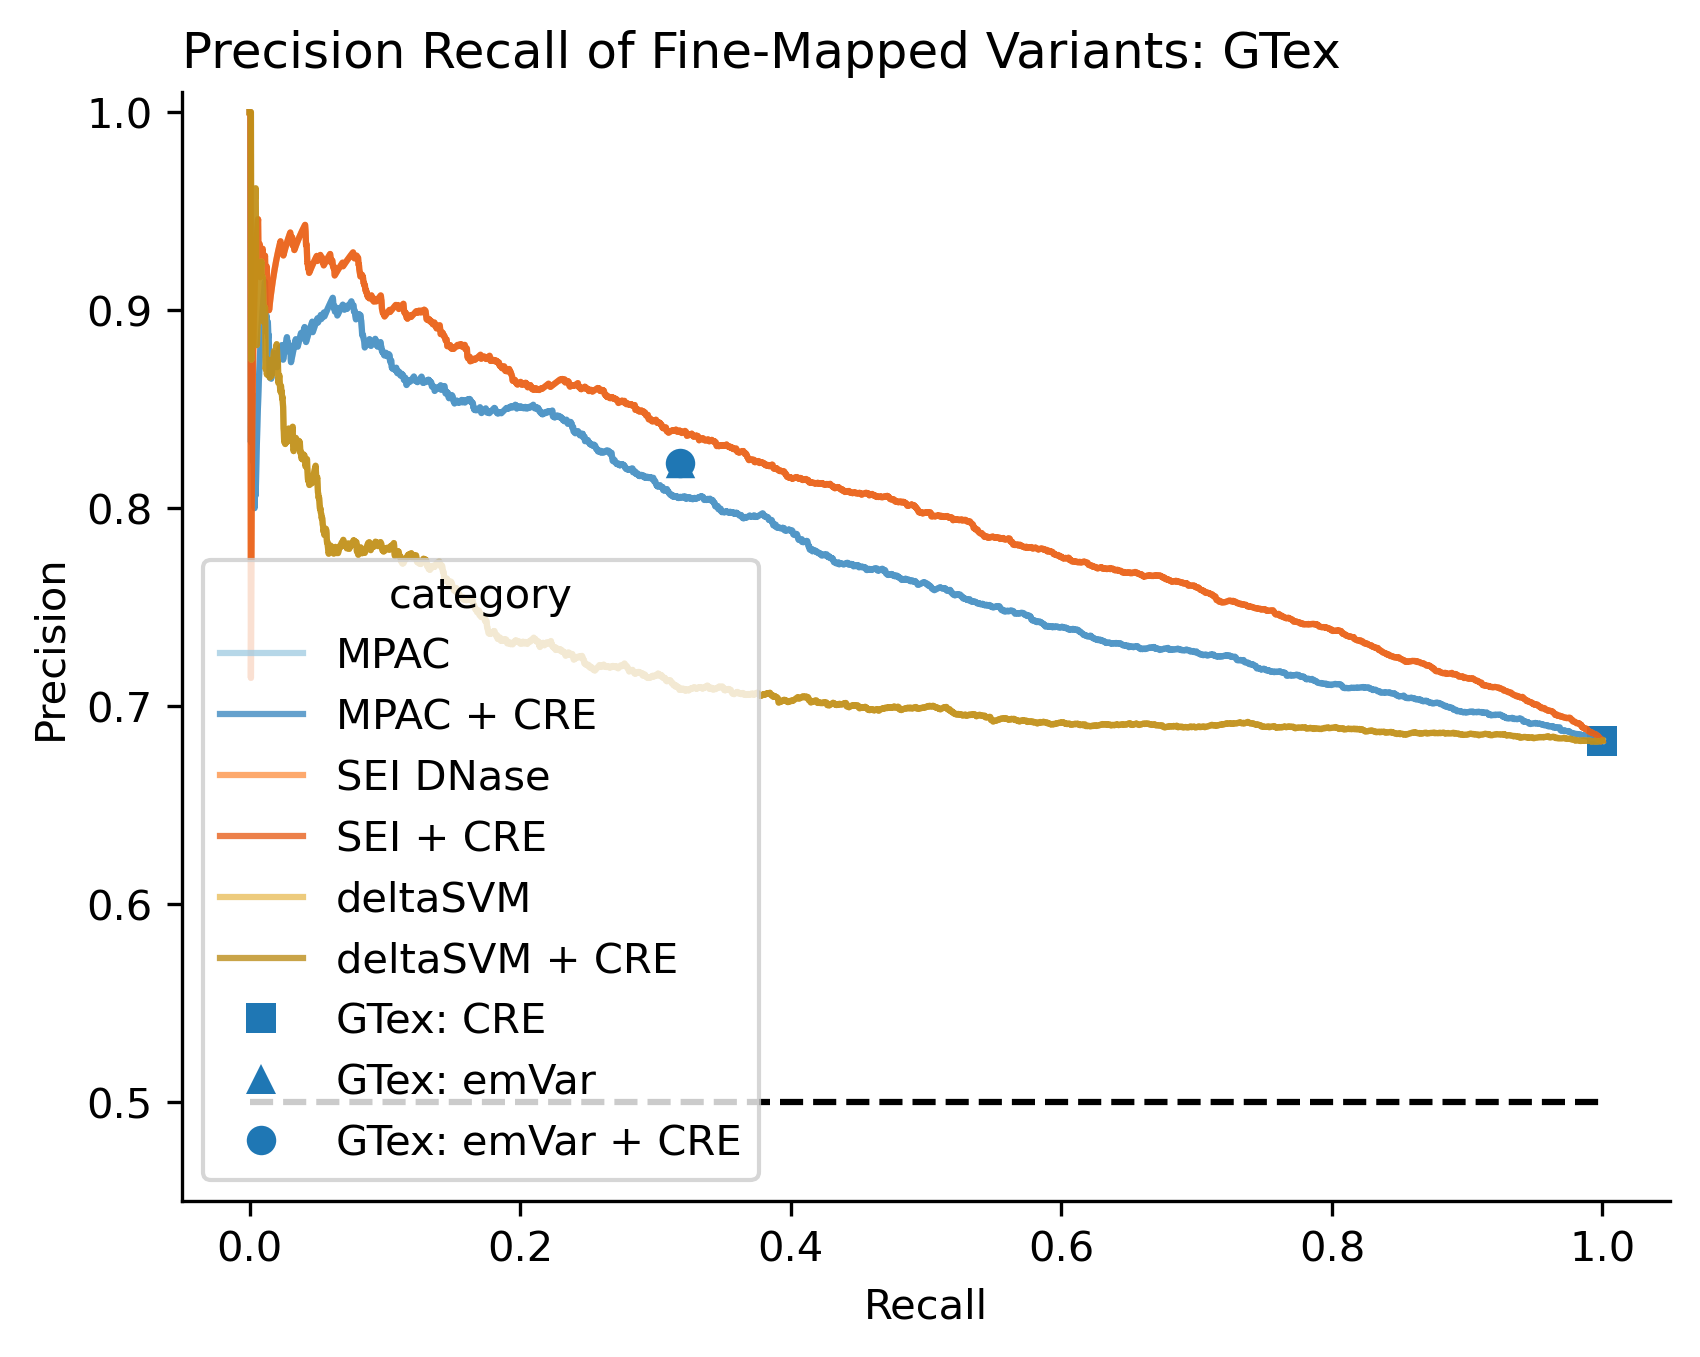

In [27]:
# plot GTeX - in CRE
gtex_prc_df, gtex_emp_prc = sklearn_precision_recall(all_gtex_with_svm[all_gtex_with_svm['CRE'] == 1].copy(),
                         'GTex',
                         gtex_palette,
                         (.45,1.01),
                         'Precision Recall of Fine-Mapped Variants: GTex',
                         '../analysis/gtex_sklearn_prc_no_act_filter_with_indels_CRE_rev1_v1.pdf',
                         '../analysis/gtex_prc_summary_with_indels_CRE_only_rev1.txt')

  library  n_vars  n_causal  n_benign  no_act_auc  no_act_cre_auc   sei_auc  \
0    UKBB     783       548       235    0.812901        0.812901  0.832801   

   sei_cre_auc  deltaSVM_auc  deltaSVM_cre_auc  
0     0.832801      0.776881          0.776881  


MPAC Precision at empirical emVar recall: 0.833976833976834
0.39416058394160586
MPAC Precision at empirical emVar + CRE recall: 0.833976833976834


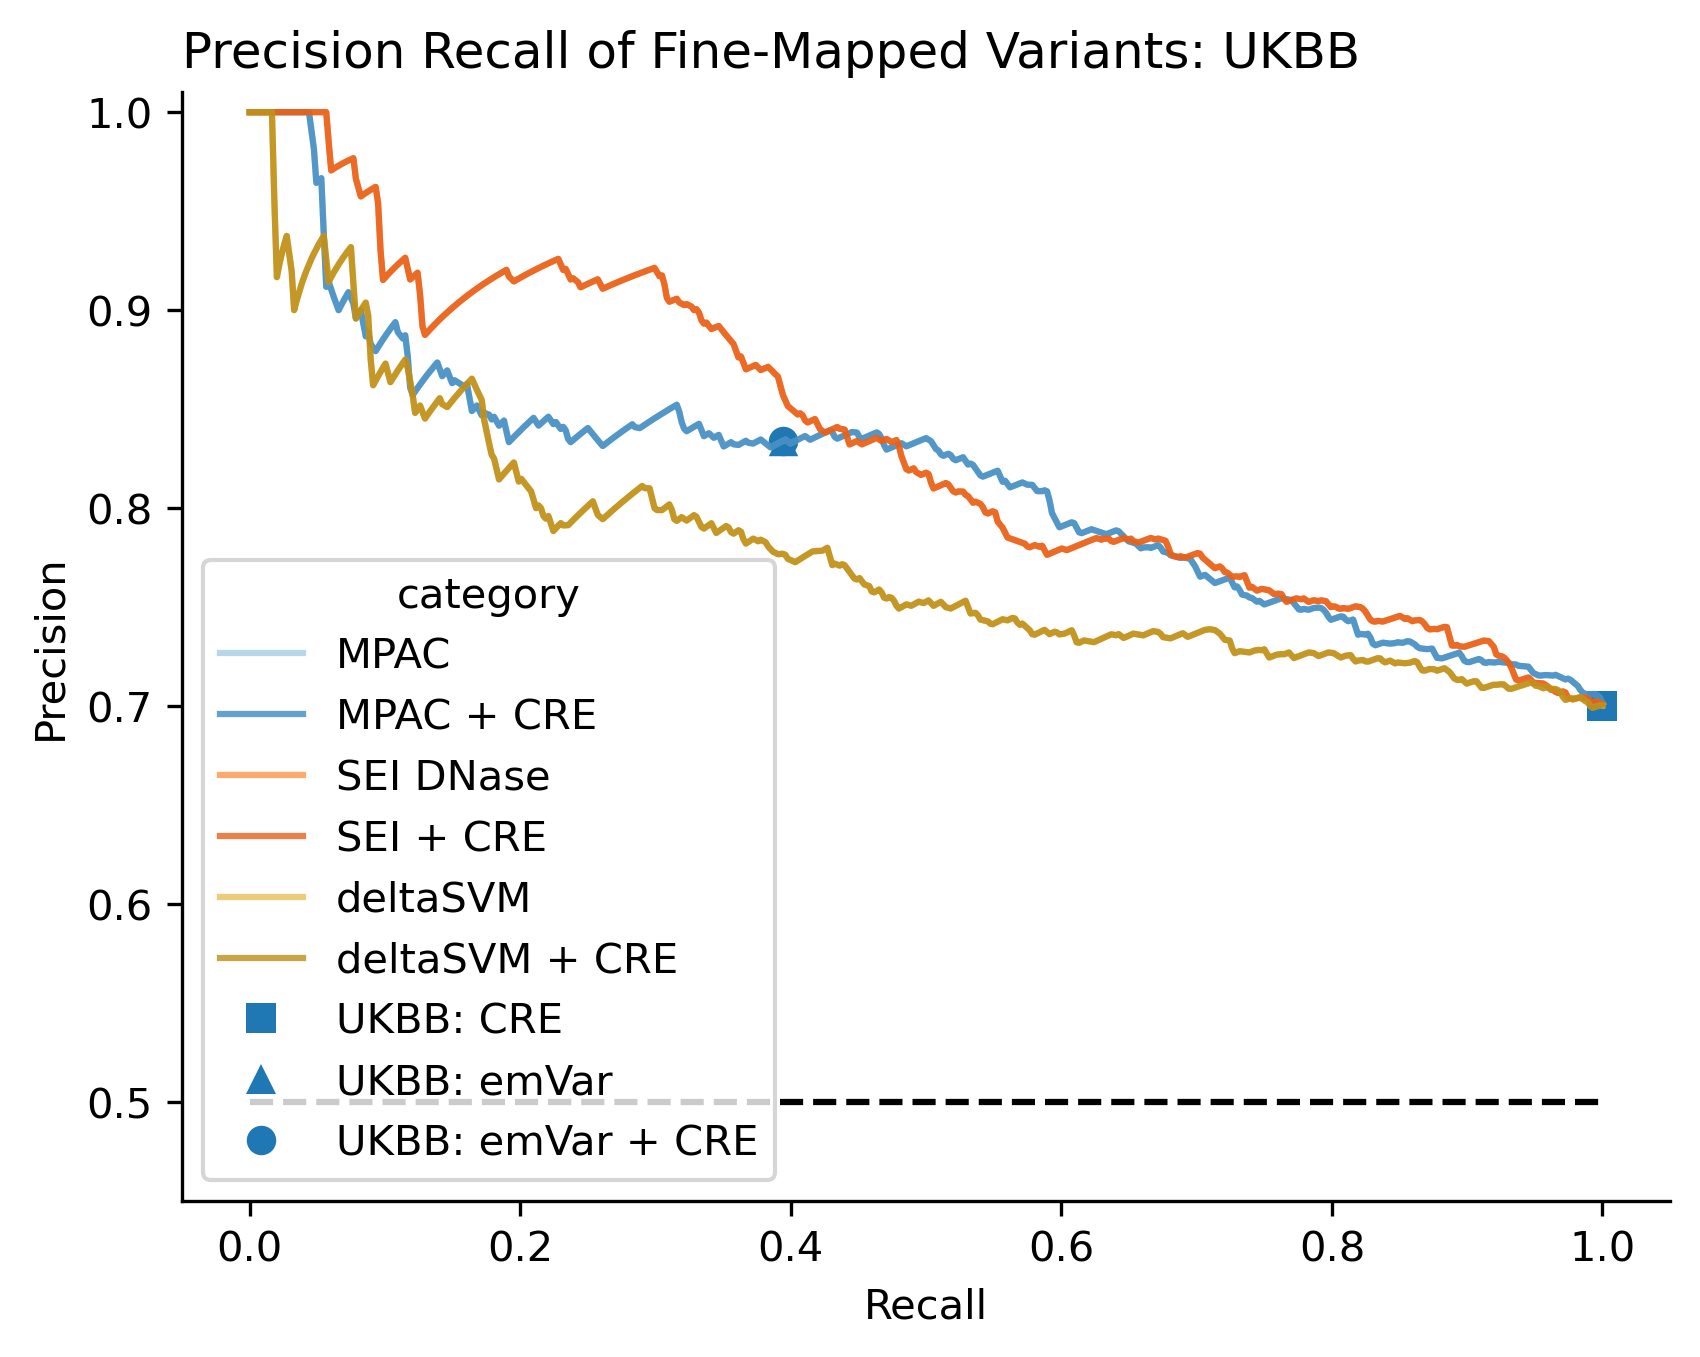

In [28]:
# plot UKBB - no activity filter
ukbb_prc_df, ukbb_emp_prc = sklearn_precision_recall(all_traits_with_svm[all_traits_with_svm['CRE'] == 1].copy(),
                         'UKBB',
                         traits_palette,
                         (.45,1.01),
                         'Precision Recall of Fine-Mapped Variants: UKBB',
                         '../analysis/ukbb_sklearn_prc_no_act_filter_with_indels_CRE_rev1_v1.pdf',
                         '../analysis/ukbb_prc_summary_with_indels_CRE_only_rev1.txt')